# Sid — Classification Models

Predicting county-level presidential election winner (party_winner: 0=Republican, 1=Democrat)
using demographic and socioeconomic features.

**Input:** `../data/processed/model_ready_dataset.csv`
**Models:** Logistic Regression, Random Forest, XGBoost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### (2) Load dataset

In [3]:
df = pd.read_csv(
    "../data/processed/model_ready_dataset.csv",
    dtype={"county_fips": str},
    low_memory=False
)

print(f"Shape: {df.shape}")
print(f"Party winner distribution:")
print(df["party_winner"].value_counts().rename({1:"Democrat", 0:"Republican"}))

Shape: (3115, 184)
Party winner distribution:
party_winner
Republican    2576
Democrat       539
Name: count, dtype: int64


### (3) Feature selection

In [4]:
# Use the engineered features from EDA — these are the strongest predictors
features = [
    "higher_ed_rate",
    "poverty_rate",
    "unemployment_rate",
    "white_pct",
    "black_pct",
    "asian_pct",
    "median_income",
    "log_population",
    "housing_density"
]

target = "party_winner"

# Drop rows with any missing values in selected features
model_df = df[features + [target]].dropna()

print(f"Rows after dropping NaN: {len(model_df)}")
print(f"Features: {len(features)}")
print(f"Target: {target}")

Rows after dropping NaN: 3114
Features: 9
Target: party_winner


### (4) Train/test split

In [5]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts().rename({1:"Democrat", 0:"Republican"}))
print(f"\nTest target distribution:")
print(y_test.value_counts().rename({1:"Democrat", 0:"Republican"}))

Training set:   (2491, 9)
Test set:       (623, 9)

Training target distribution:
party_winner
Republican    2060
Democrat       431
Name: count, dtype: int64

Test target distribution:
party_winner
Republican    515
Democrat      108
Name: count, dtype: int64


### (5) Feature scaling

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Mean of first feature (train): {X_train_scaled[:, 0].mean():.4f}")
print(f"Std  of first feature (train): {X_train_scaled[:, 0].std():.4f}")

Features scaled successfully.
Mean of first feature (train): -0.0000
Std  of first feature (train): 1.0000


### (6) Model 1 — Logistic Regression

In [7]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Results:")
print("=" * 45)
print(classification_report(y_test, y_pred_lr,
      target_names=["Republican", "Democrat"]))

Logistic Regression Results:
              precision    recall  f1-score   support

  Republican       0.98      0.88      0.93       515
    Democrat       0.61      0.90      0.73       108

    accuracy                           0.88       623
   macro avg       0.79      0.89      0.83       623
weighted avg       0.91      0.88      0.89       623



### (7) Model 2 — Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Results:")
print("=" * 45)
print(classification_report(y_test, y_pred_rf,
      target_names=["Republican", "Democrat"]))

Random Forest Results:
              precision    recall  f1-score   support

  Republican       0.95      0.97      0.96       515
    Democrat       0.82      0.76      0.79       108

    accuracy                           0.93       623
   macro avg       0.89      0.86      0.87       623
weighted avg       0.93      0.93      0.93       623



### (8) Model 3 — XGBoost

In [9]:
# Calculate scale_pos_weight to handle imbalance
neg = (y_train == 0).sum()  # Republican
pos = (y_train == 1).sum()  # Democrat
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print(f"scale_pos_weight used: {scale:.2f}")
print("\nXGBoost Results:")
print("=" * 45)
print(classification_report(y_test, y_pred_xgb,
      target_names=["Republican", "Democrat"]))

scale_pos_weight used: 4.78

XGBoost Results:
              precision    recall  f1-score   support

  Republican       0.96      0.94      0.95       515
    Democrat       0.74      0.80      0.77       108

    accuracy                           0.92       623
   macro avg       0.85      0.87      0.86       623
weighted avg       0.92      0.92      0.92       623



### (9) Confusion matrices

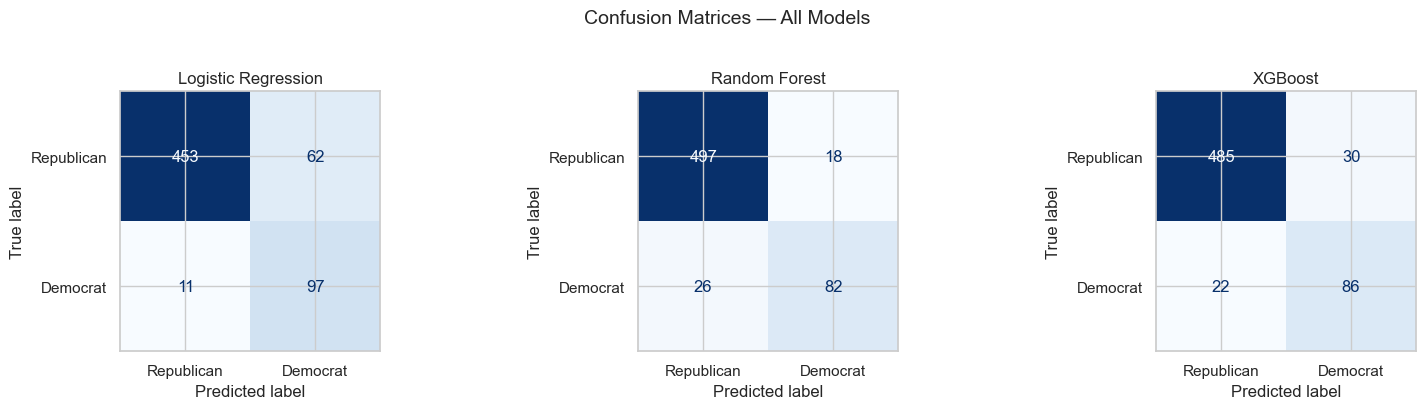

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
    ("XGBoost",             y_pred_xgb),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Republican", "Democrat"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(model_name)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### (10) ROC curves

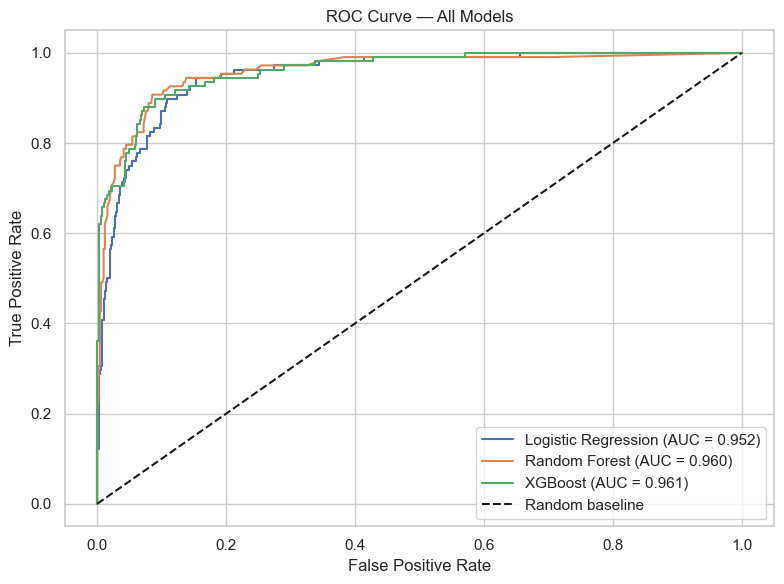

In [11]:
plt.figure(figsize=(8, 6))

for model_name, model in [
    ("Logistic Regression", lr),
    ("Random Forest",       rf),
    ("XGBoost",             xgb),
]:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend()
plt.tight_layout()
plt.show()

### (11) Feature importance — Random Forest

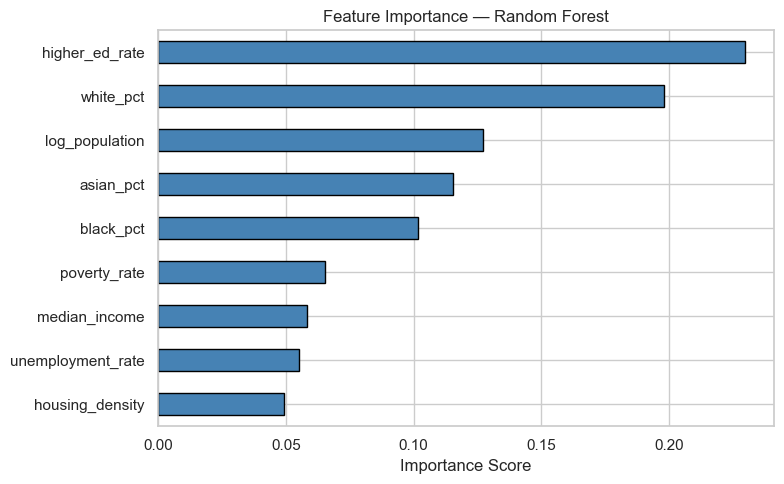


Feature importance ranking:
higher_ed_rate       0.2295
white_pct            0.1979
log_population       0.1270
asian_pct            0.1155
black_pct            0.1019
poverty_rate         0.0654
median_income        0.0582
unemployment_rate    0.0552
housing_density      0.0493
dtype: float64


In [12]:
feat_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
print(feat_importance.sort_values(ascending=False).round(4))

### (12) Model comparison summary

In [13]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy":          [0.88, 0.93, 0.92],
    "Democrat F1":       [0.73, 0.79, 0.77],
    "Democrat Precision":[0.61, 0.82, 0.74],
    "Democrat Recall":   [0.90, 0.76, 0.80],
    "ROC AUC":           [0.952, 0.960, 0.961],
})

results = results.set_index("Model")

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
display(results)
print("\nBest model overall: Random Forest")
print("  - Highest accuracy (0.93)")
print("  - Highest Democrat F1 (0.79)")
print("  - Highest Democrat Precision (0.82)")
print("  - Second best AUC (0.960)")

MODEL COMPARISON SUMMARY


,Accuracy,Democrat F1,Democrat Precision,Democrat Recall,ROC AUC
Model,,,,,
Logistic Regression,0.88,0.73,0.61,0.90,0.952
Random Forest,0.93,0.79,0.82,0.76,0.960
XGBoost,0.92,0.77,0.74,0.80,0.961



Best model overall: Random Forest
  - Highest accuracy (0.93)
  - Highest Democrat F1 (0.79)
  - Highest Democrat Precision (0.82)
  - Second best AUC (0.960)
